## Human group counting model

Imports

In [12]:
import os, math
from pathlib import Path
import numpy as np
import scipy.io as sio
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models


Settings

In [28]:
DATA_ROOT = "./shanghaitech"   # ← change to your dataset path
BATCH_SIZE = 8
LR = 1e-3
EPOCHS = 20
IMG_SIZE = (265, 512)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset

In [14]:
class ShanghaiTechGlobalCount(Dataset):
    def __init__(self, root_dir, split="train", img_size=IMG_SIZE, transform=None):
        assert split in ("train", "test")
        self.root_dir = Path(root_dir)
        folder = "part_B_train_data" if split == "train" else "part_B_test_data"
        self.img_dir = self.root_dir / folder / "images"
        self.gt_dir  = self.root_dir / folder / "ground_truth"
        self.files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.lower().endswith(".jpg") or f.lower().endswith(".png")
        ])
        self.img_size = img_size
        self.transform = transform or T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406],
                        std=[0.229,0.224,0.225]),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img_path = str(self.img_dir / fname)
        gt_path = str(self.gt_dir / ("GT_" + os.path.splitext(fname)[0].replace("processed_","") + ".mat"))

        img = Image.open(img_path).convert("RGB")
        mat = sio.loadmat(gt_path)
        points = mat["image_info"][0,0][0,0][0]
        count = float(points.shape[0])
        img = self.transform(img)
        return img, torch.tensor(count, dtype=torch.float32)


model

In [15]:
class GlobalRegressorResNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        )
        in_feat = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_feat, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

training

In [16]:
def evaluate(model, loader, device):
    model.eval()
    mae = mse = n = 0
    with torch.no_grad():
        for imgs, counts in loader:
            imgs, counts = imgs.to(device), counts.to(device)
            preds = model(imgs).clamp(min=0)
            mae += (preds - counts).abs().sum().item()
            mse += ((preds - counts) ** 2).sum().item()
            n += imgs.size(0)
    return mae / n, math.sqrt(mse / n)

def train_full(data_root, train_loader, test_loader, batch_size=8, lr=1e-4, n_epochs=12):
    model = GlobalRegressorResNet(pretrained=True).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_mae = float("inf")
    train_losses = []  # ← store loss per epoch

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.8)  # halve lr every 5 epochs

    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss = 0.0
        for imgs, counts in train_loader:
            imgs, counts = imgs.to(DEVICE), counts.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, counts)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)  # ← store

        val_mae, val_rmse = evaluate(model, test_loader, DEVICE)
        print(f"Epoch {epoch:02d}: TrainLoss={train_loss:.4f} | ValMAE={val_mae:.2f} | ValRMSE={val_rmse:.2f}")
        scheduler.step()
        if val_mae < best_mae:
            best_mae = val_mae
            torch.save(model.state_dict(), "best_resnet_global_count_humans.pth")

    print("Training done. Best MAE:", best_mae)

    # Plot training loss
    plt.figure(figsize=(8,5))
    plt.plot(range(1, n_epochs+1), train_losses, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss (MSE)")
    plt.title("Training Loss Over Epochs")
    plt.grid(True)
    plt.show()

    return model

Visualizations

In [17]:
def visualize_examples(data_root, checkpoint="best_resnet_global_count.pth", n_examples=8):
    test_ds = ShanghaiTechGlobalCount(data_root, split="test", transform=T.Compose([
        T.Resize(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406],
                    std=[0.229,0.224,0.225]),
    ]))
    loader = DataLoader(test_ds, batch_size=n_examples, shuffle=False)
    imgs, counts = next(iter(loader))

    model = GlobalRegressorResNet(pretrained=True).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    model.eval()

    with torch.no_grad():
        preds = model(imgs.to(DEVICE)).cpu().numpy()

    plt.figure(figsize=(12,6))
    for i in range(min(n_examples, imgs.size(0))):
        ax = plt.subplot(2, math.ceil(n_examples / 2), i + 1)
        img_vis = imgs[i].clone()
        img_vis = img_vis * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        plt.imshow(img_vis.permute(1,2,0).numpy().clip(0,1))
        plt.title(f"GT: {int(counts[i].item())}, Pred: {preds[i]:.1f}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [18]:
def visualize_last_layer(data_root, checkpoint="best_resnet_global_count.pth", n_examples=4):
    model = GlobalRegressorResNet(pretrained=True).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    model.eval()

    test_ds = ShanghaiTechGlobalCount(data_root, split="test", transform=T.Compose([
        T.Resize(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406],
                    std=[0.229,0.224,0.225]),
    ]))
    loader = DataLoader(test_ds, batch_size=n_examples, shuffle=False)
    imgs, counts = next(iter(loader))

    # Hook to grab last conv feature maps
    features = []
    def hook_fn(module, input, output):
        features.append(output)

    handle = model.backbone.layer1.register_forward_hook(hook_fn)

    with torch.no_grad():
        preds = model(imgs.to(DEVICE)).cpu().numpy()

    handle.remove()  # unregister hook
    feature_maps = features[0].cpu()  # shape: [B, C, H, W]

    # visualize
    plt.figure(figsize=(12, 6))
    for i in range(min(n_examples, imgs.size(0))):
        ax = plt.subplot(2, n_examples, i+1)
        img_vis = imgs[i].clone()
        img_vis = img_vis * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        plt.imshow(img_vis.permute(1,2,0).numpy().clip(0,1))
        plt.title(f"GT: {int(counts[i].item())}, Pred: {preds[i]:.1f}")
        plt.axis("off")

        # heatmap from mean of last layer channels
        ax2 = plt.subplot(2, n_examples, n_examples + i + 1)
        fmap = feature_maps[i].mean(0)  # mean across channels
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min())  # normalize 0-1
        plt.imshow(fmap.numpy(), cmap='jet', alpha=0.6)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [49]:
def visualize_image(img_path, checkpoint, device=DEVICE):
    """
    Visualize prediction and last conv layer for a single image.
    """
    model = GlobalRegressorResNet(pretrained=True).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    model.eval()

    # Load and preprocess image
    img = Image.open(img_path).convert("RGB")
    transform = T.Compose([
        T.Resize(IMG_SIZE),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225]),
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)  # shape [1,3,H,W]

    # Hook to grab last conv layer output
    features = []

    def hook_fn(module, input, output):
        features.append(output)

    handle = model.backbone.layer4.register_forward_hook(hook_fn)

    # Forward pass
    model.eval()
    with torch.no_grad():
        pred = model(img_tensor).item()

    handle.remove()
    feature_map = features[0].squeeze(0).cpu()  # shape [C,H,W]

    # Visualization
    plt.figure(figsize=(8, 4))

    # Original image
    ax1 = plt.subplot(1, 2, 1)
    img_vis = img_tensor[0].cpu().clone()
    img_vis = img_vis * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3,
                                                                                                                     1,
                                                                                                                     1)
    plt.imshow(img_vis.permute(1, 2, 0).numpy().clip(0, 1))
    plt.title(f"Predicted Count: {pred:.1f}")
    plt.axis("off")

    # Heatmap from last conv layer
    ax2 = plt.subplot(1, 2, 2)
    fmap = feature_map.mean(0)  # mean across channels
    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min())
    plt.imshow(fmap.numpy(), cmap='jet', alpha=0.6)
    plt.title("Last Conv Layer Activation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



In [44]:
def visualize_last_layer_temp(test_loader, checkpoint="best_resnet_global_count.pth", n_examples=4):
    model = GlobalRegressorResNet(pretrained=True).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    model.eval()

    imgs, counts = next(iter(test_loader))

    # Hook to grab last conv feature maps
    features = []
    def hook_fn(module, input, output):
        features.append(output)

    handle = model.backbone.layer4.register_forward_hook(hook_fn)

    with torch.no_grad():
        preds = model(imgs.to(DEVICE)).cpu().numpy()

    handle.remove()  # unregister hook
    feature_maps = features[0].cpu()  # shape: [B, C, H, W]

    # visualize
    plt.figure(figsize=(12, 6))
    for i in range(min(n_examples, imgs.size(0))):
        ax = plt.subplot(2, n_examples, i+1)
        img_vis = imgs[i].clone()
        img_vis = img_vis * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        plt.imshow(img_vis.permute(1,2,0).numpy().clip(0,1))
        plt.title(f"GT: {int(counts[i].item())}, Pred: {preds[i]:.1f}")
        plt.axis("off")

        # heatmap from mean of last layer channels
        ax2 = plt.subplot(2, n_examples, n_examples + i + 1)
        fmap = feature_maps[i].mean(0)  # mean across channels
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min())  # normalize 0-1
        plt.imshow(fmap.numpy(), cmap='jet', alpha=0.6)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

Run everything

In [36]:
if not os.path.exists(DATA_ROOT):
    raise RuntimeError(f"Dataset not found at {DATA_ROOT}. Please download and extract ShanghaiTech Part B.")

img_size = IMG_SIZE
transform = T.Compose([
    T.Resize(img_size),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]),
])

train_ds = ShanghaiTechGlobalCount(DATA_ROOT, split="train", transform=transform)
test_ds = ShanghaiTechGlobalCount(DATA_ROOT, split="test", transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Epoch 01: TrainLoss=10605.0710 | ValMAE=67.25 | ValRMSE=102.91
Epoch 02: TrainLoss=4688.3542 | ValMAE=64.60 | ValRMSE=95.18
Epoch 03: TrainLoss=4650.9912 | ValMAE=55.67 | ValRMSE=80.89
Epoch 04: TrainLoss=4368.7723 | ValMAE=73.23 | ValRMSE=90.13
Epoch 05: TrainLoss=4109.1293 | ValMAE=35.86 | ValRMSE=58.27
Epoch 06: TrainLoss=3621.0633 | ValMAE=70.75 | ValRMSE=106.53
Epoch 07: TrainLoss=3735.1070 | ValMAE=137.37 | ValRMSE=178.21
Epoch 08: TrainLoss=3262.7062 | ValMAE=37.80 | ValRMSE=58.03
Epoch 09: TrainLoss=3262.5426 | ValMAE=186.49 | ValRMSE=208.43
Epoch 10: TrainLoss=3048.5916 | ValMAE=39.86 | ValRMSE=52.16
Epoch 11: TrainLoss=2665.3616 | ValMAE=57.35 | ValRMSE=76.41
Epoch 12: TrainLoss=2784.0244 | ValMAE=30.15 | ValRMSE=47.42
Epoch 13: TrainLoss=2780.1946 | ValMAE=39.92 | ValRMSE=58.52
Epoch 14: TrainLoss=2795.3466 | ValMAE=41.53 | ValRMSE=61.89
Epoch 15: TrainLoss=2652.9914 | ValMAE=31.89 | ValRMSE=48.72
Epoch 16: TrainLoss=2809.4422 | ValMAE=61.35 | ValRMSE=86.51
Epoch 17: TrainLo

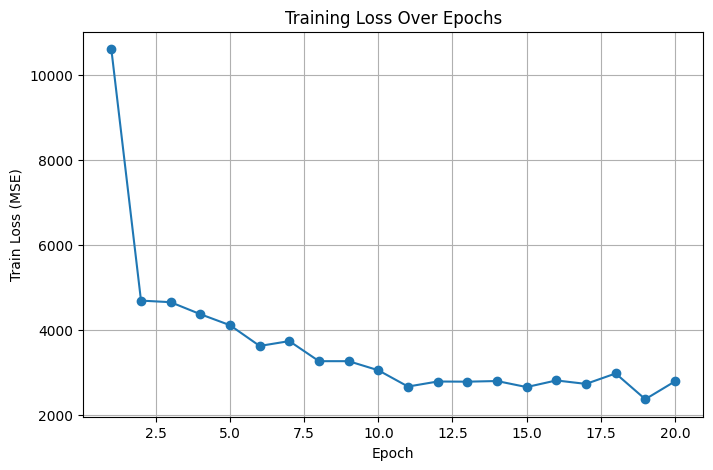

In [37]:
model = train_full(DATA_ROOT, train_loader, test_loader, batch_size=BATCH_SIZE, lr=LR, n_epochs=EPOCHS)

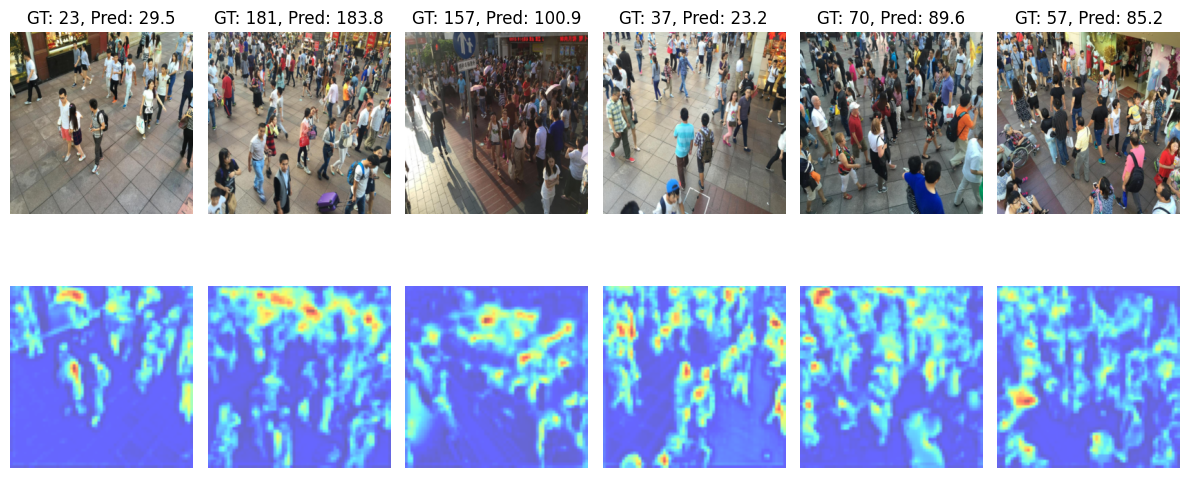

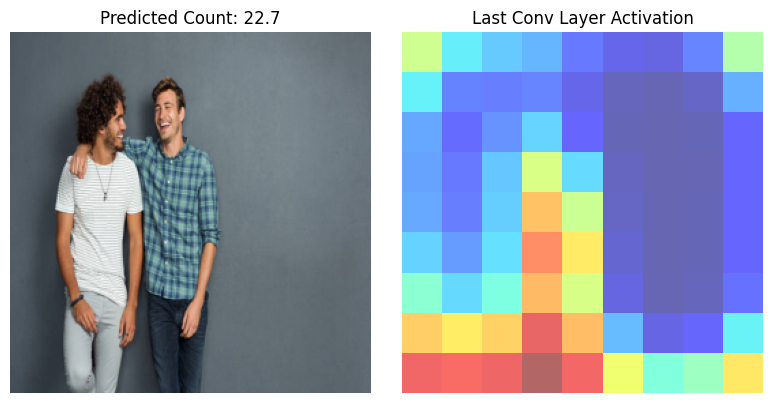

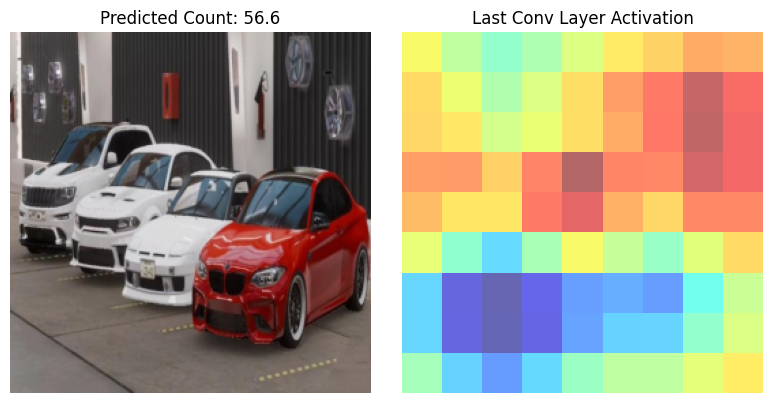

In [52]:

visualize_last_layer_temp(test_loader, checkpoint="best_resnet_global_count_humans.pth", n_examples=6)
visualize_image("personal_tests/img.png", checkpoint="best_resnet_global_count_humans.pth", device=DEVICE)
visualize_image("personal_tests/img_2.png", checkpoint="best_resnet_global_count_humans.pth", device=DEVICE)